Final analytical notebook. Run and save in Google Colab before submission.


# 02 | Data Preparation and Baseline Forecasting

This is the first notebook in the final forecasting stage. Notebook 01 was used to check whether the datasets were suitable. Here I prepare the M5 demand data and test two baseline methods before moving to LightGBM.

The forecast is produced at category-store level. There are three product categories and ten stores, giving 30 daily series. Each model is tested over a 28-day horizon.

The main questions are:

1. Can the raw M5 sales file be converted into 30 complete daily series?
2. How well does a simple weekly forecast perform?
3. Does Holt-Winters provide a stronger baseline for comparison with LightGBM?


## 1. Set up the project

The random state, 28-day horizon and four test periods are stored in the project configuration. I kept these settings fixed so that the comparison would not change after seeing the results. Repeated functions are kept in `src` so that the same calculations are used throughout the project.


In [2]:
from pathlib import Path
import sys

try:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/MSc_Dissertation_Forecasting_Final")
except ImportError:
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    PROJECT_ROOT = next(
        (path for path in candidates if (path / "src").is_dir()),
        Path.cwd().resolve(),
    )

if not (PROJECT_ROOT / "src").is_dir():
    raise FileNotFoundError(
        f"Project source folder not found under {PROJECT_ROOT}."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.project_paths import ProjectPaths

PATHS = ProjectPaths(PROJECT_ROOT)
PATHS.ensure_output_directories()

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.baselines import holt_winters_forecasts, seasonal_naive_forecasts
from src.config import FOLDS, HORIZON, RANDOM_STATE, SEASONAL_PERIOD
from src.data_pipeline import build_category_store_panel
from src.evaluation import build_metric_table

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

print(f"Project root: {PROJECT_ROOT}")
print(f"Random state: {RANDOM_STATE}")
print(f"Forecast horizon: {HORIZON} days")
print(f"Seasonal period: {SEASONAL_PERIOD} days")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/MSc_Dissertation_Forecasting_Final
Random state: 42
Forecast horizon: 28 days
Seasonal period: 7 days


## 2. Build the category-store data

The M5 sales file contains 30,490 item-store rows, with a separate column for each historical day. Modelling every item-store combination would make the project much larger and would not match the dashboard's intended planning level. I therefore sum item demand within each category and store:

\[
y_{c,s,t}=\sum_{i \in c} y_{i,s,t}
\]

where \(y_{c,s,t}\) is total demand for category \(c\), store \(s\), and day \(t\). This gives 30 series. The file is read in chunks because keeping the complete wide sales table in memory is unnecessary.


In [3]:
sales_path = PATHS.m5_file("sales_train_evaluation.csv")
calendar_path = PATHS.m5_file("calendar.csv")
panel_path = PATHS.processed / "m5_category_store_panel.csv"

if not calendar_path.exists():
    raise FileNotFoundError(f"Required M5 calendar is missing: {calendar_path}")

# The verified processed panel is included in the final project. Change this
# to True only when rebuilding from the official complete M5 evaluation file.
REBUILD_PANEL = False
if REBUILD_PANEL or not panel_path.exists():
    if not sales_path.exists():
        raise FileNotFoundError(
            "A complete sales_train_evaluation.csv is required only when "
            "rebuilding the processed panel. See data/README.md."
        )
    panel = build_category_store_panel(sales_path, calendar_path)
    panel_path.parent.mkdir(parents=True, exist_ok=True)
    panel.to_csv(panel_path, index=False)
    panel_source = "rebuilt from raw M5 files"
else:
    panel = pd.read_csv(panel_path, parse_dates=["date"])
    panel_source = "loaded from the reproducible processed file"

print(f"Panel {panel_source}.")
print(f"Rows: {len(panel):,}")
print(f"Memory used: {panel.memory_usage(deep=True).sum() / 1_000_000:,.2f} MB")


Panel loaded from the reproducible processed file.
Rows: 58,230
Memory used: 5.50 MB


## 3. Check the processed data

Before fitting any model, I check that the processed panel has the expected structure:

- exactly 30 unique category-store series;
- exactly 1,941 observations per series;
- one observation per series-day key;
- no missing or negative demand;
- a continuous daily calendar from 29 January 2011 to 22 May 2016.

If one of these checks fails, the notebook stops before modelling.


In [4]:
series_lengths = panel.groupby("series_id", observed=True).size()
validation = pd.DataFrame(
    {
        "check": [
            "Unique series",
            "Rows",
            "Days per series (minimum)",
            "Days per series (maximum)",
            "Duplicate series-day keys",
            "Missing demand values",
            "Negative demand values",
            "First date",
            "Last date",
        ],
        "observed": [
            panel["series_id"].nunique(),
            len(panel),
            series_lengths.min(),
            series_lengths.max(),
            panel.duplicated(["series_id", "day_number"]).sum(),
            panel["actual"].isna().sum(),
            panel["actual"].lt(0).sum(),
            panel["date"].min().date(),
            panel["date"].max().date(),
        ],
        "expected": [30, 30 * 1941, 1941, 1941, 0, 0, 0, "2011-01-29", "2016-05-22"],
    }
)

assert panel["series_id"].nunique() == 30
assert len(panel) == 30 * 1941
assert series_lengths.eq(1941).all()
assert not panel.duplicated(["series_id", "day_number"]).any()
assert panel["actual"].notna().all()
assert panel["actual"].ge(0).all()
display(validation)


,check,observed,expected
0,Unique series,30,30
1,Rows,58230,58230
2,Days per series (minimum),1941,1941
3,Days per series (maximum),1941,1941
4,Duplicate series-day keys,0,0
5,Missing demand values,0,0
6,Negative demand values,0,0
7,First date,2011-01-29,2011-01-29
8,Last date,2016-05-22,2016-05-22


The final panel contains 58,230 rows: 30 series multiplied by 1,941 days. This level is detailed enough to compare categories across stores but more manageable than 30,490 item-level series. It does not support individual SKU replenishment decisions.


,category,store,state,days,mean_daily_demand,demand_sd,total_demand,zero_days
0,FOODS,CA_1,CA,1941,"2,818.9907",701.4429,5471661,5
1,FOODS,CA_2,CA,1941,"1,837.9583",599.4075,3567477,0
2,FOODS,CA_3,CA,1941,"3,928.7275",801.0753,7625660,1
3,FOODS,CA_4,CA,1941,"1,479.1680",288.0831,2871065,5
4,FOODS,TX_1,TX,1941,"1,978.6471",415.5324,3840554,3
5,FOODS,TX_2,TX,1941,"2,623.0613",573.1513,5091362,3
6,FOODS,TX_3,TX,1941,"2,184.5389",440.3153,4240190,0
7,FOODS,WI_1,WI,1941,"1,812.0994",751.0932,3517285,3
8,FOODS,WI_2,WI,1941,"2,515.3617","1,004.9798",4882317,2
9,FOODS,WI_3,WI,1941,"2,480.6059",684.9433,4814856,2


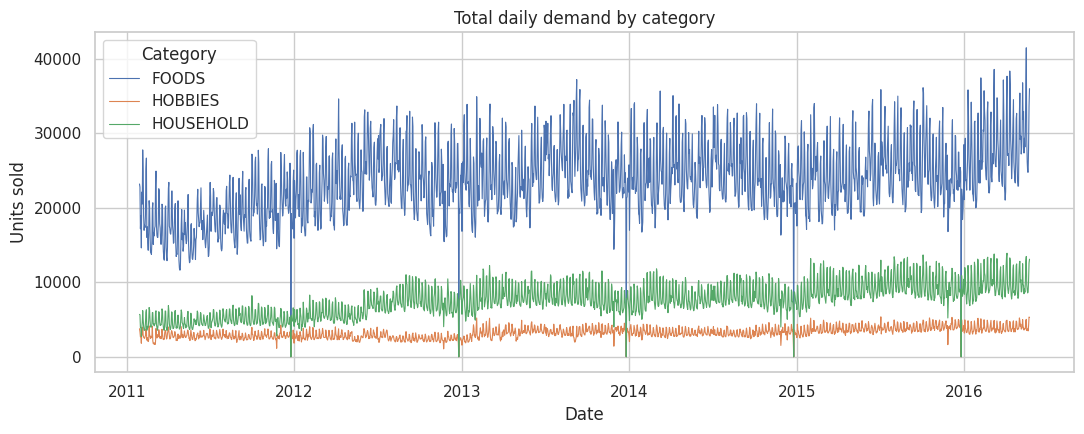

In [5]:
series_summary = (
    panel.groupby(["category", "store", "state"], observed=True)["actual"]
    .agg(
        days="size",
        mean_daily_demand="mean",
        demand_sd="std",
        total_demand="sum",
        zero_days=lambda values: values.eq(0).sum(),
    )
    .reset_index()
)
display(series_summary.head(10))

category_daily = (
    panel.groupby(["date", "category"], observed=True)["actual"]
    .sum()
    .reset_index()
)
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.lineplot(data=category_daily, x="date", y="actual", hue="category", linewidth=0.8, ax=ax)
ax.set(title="Total daily demand by category", xlabel="Date", ylabel="Units sold")
ax.legend(title="Category", frameon=True)
fig.tight_layout()
display(fig)
plt.close(fig)


The three categories have different demand levels and visible movement over time. This is one reason I retain category information in the later LightGBM model and use a scaled error measure when comparing series.

## 4. Define the four historical tests

A random train-test split would mix earlier and later dates. That is inappropriate for forecasting because a model should only learn from the past. I use four consecutive 28-day tests instead. For each test, training ends before the forecast period begins.

The four test windows do not overlap and together cover the final 112 observed days.


In [6]:
calendar_lookup = (
    panel[["day_number", "date"]]
    .drop_duplicates()
    .set_index("day_number")["date"]
)
fold_table = pd.DataFrame(
    [
        {
            "fold": fold.fold_id,
            "training_end_day": f"d_{fold.origin_day}",
            "training_end_date": calendar_lookup.loc[fold.origin_day].date(),
            "test_start_day": f"d_{fold.test_start_day}",
            "test_start_date": calendar_lookup.loc[fold.test_start_day].date(),
            "test_end_day": f"d_{fold.test_end_day}",
            "test_end_date": calendar_lookup.loc[fold.test_end_day].date(),
            "horizon_days": fold.test_end_day - fold.test_start_day + 1,
        }
        for fold in FOLDS
    ]
)
assert fold_table["horizon_days"].eq(28).all()
display(fold_table)


,fold,training_end_day,training_end_date,test_start_day,test_start_date,test_end_day,test_end_date,horizon_days
0,F1,d_1829,2016-01-31,d_1830,2016-02-01,d_1857,2016-02-28,28
1,F2,d_1857,2016-02-28,d_1858,2016-02-29,d_1885,2016-03-27,28
2,F3,d_1885,2016-03-27,d_1886,2016-03-28,d_1913,2016-04-24,28
3,F4,d_1913,2016-04-24,d_1914,2016-04-25,d_1941,2016-05-22,28


## 5. Baseline 1: repeat the previous week

The seasonal-naive method repeats the last seven observed values:

\[
\hat{y}_{t+h}=y_{t+h-7k}
\]

where \(k\) is chosen so the referenced value lies in the final observed seven-day pattern. For a 28-day horizon, that weekly pattern is repeated four times.

This gives a simple but relevant benchmark because retail demand often follows a weekly pattern. The seven values come only from the training period.


In [7]:
seasonal_forecasts, rmsse_scales = seasonal_naive_forecasts(panel)

assert len(seasonal_forecasts) == 30 * 4 * 28
assert seasonal_forecasts["forecast"].notna().all()
assert seasonal_forecasts["forecast"].ge(0).all()

example = seasonal_forecasts.query("fold_id == 'F1' and series_id == 'FOODS_CA_1'")
display(example[["forecast_date", "horizon_day", "actual", "forecast", "error"]].head(10))
print(f"Seasonal-naive forecasts generated: {len(seasonal_forecasts):,}")


,forecast_date,horizon_day,actual,forecast,error
0,2016-02-01,1,"2,606.0000","2,289.0000",317.0000
1,2016-02-02,2,"2,467.0000","2,049.0000",418.0000
2,2016-02-03,3,"2,537.0000","1,970.0000",567.0000
3,2016-02-04,4,"2,616.0000","2,017.0000",599.0000
4,2016-02-05,5,"2,877.0000","2,537.0000",340.0000
5,2016-02-06,6,"4,300.0000","3,481.0000",819.0000
6,2016-02-07,7,"3,464.0000","3,910.0000",-446.0000
7,2016-02-08,8,"2,592.0000","2,289.0000",303.0000
8,2016-02-09,9,"2,639.0000","2,049.0000",590.0000
9,2016-02-10,10,"2,674.0000","1,970.0000",704.0000


Seasonal-naive forecasts generated: 3,360


### Worked check: how the weekly baseline is produced

To make the function call transparent, I reproduce one forecast outside the reusable function. For `FOODS_CA_1` in Fold 1, I take the final seven actual values available at the training cutoff and repeat them four times. The independently calculated values must match the saved function output.


In [8]:
worked_series_id = "FOODS_CA_1"
worked_fold = FOLDS[0]
worked_history = (
    panel.query("series_id == @worked_series_id and day_number <= @worked_fold.origin_day")
    .sort_values("day_number")
)
last_observed_week = worked_history.tail(SEASONAL_PERIOD)[
    ["day_number", "date", "actual"]
].reset_index(drop=True)
manual_weekly_forecast = np.resize(
    last_observed_week["actual"].to_numpy(dtype=float), HORIZON
)
function_weekly_forecast = (
    seasonal_forecasts.query(
        "fold_id == @worked_fold.fold_id and series_id == @worked_series_id"
    )
    .sort_values("horizon_day")["forecast"]
    .to_numpy(dtype=float)
)

assert np.array_equal(manual_weekly_forecast, function_weekly_forecast)
display(last_observed_week)
display(
    pd.DataFrame(
        {
            "horizon_day": np.arange(1, HORIZON + 1),
            "manual_forecast": manual_weekly_forecast,
            "function_forecast": function_weekly_forecast,
        }
    ).head(10)
)
print("Worked seasonal-naive calculation matches the reusable function.")


,day_number,date,actual
0,1823,2016-01-25,2289
1,1824,2016-01-26,2049
2,1825,2016-01-27,1970
3,1826,2016-01-28,2017
4,1827,2016-01-29,2537
5,1828,2016-01-30,3481
6,1829,2016-01-31,3910


,horizon_day,manual_forecast,function_forecast
0,1,"2,289.0000","2,289.0000"
1,2,"2,049.0000","2,049.0000"
2,3,"1,970.0000","1,970.0000"
3,4,"2,017.0000","2,017.0000"
4,5,"2,537.0000","2,537.0000"
5,6,"3,481.0000","3,481.0000"
6,7,"3,910.0000","3,910.0000"
7,8,"2,289.0000","2,289.0000"
8,9,"2,049.0000","2,049.0000"
9,10,"1,970.0000","1,970.0000"


Worked seasonal-naive calculation matches the reusable function.


## 6. Baseline 2: Holt-Winters

Holt-Winters is fitted separately to each series in each fold. I use the same specification throughout:

- additive level and trend;
- damped trend;
- additive seven-day seasonality;
- parameters estimated from each fold's training history;
- negative mathematical forecasts clipped to zero because unit demand cannot be negative.

Unlike seasonal-naive, it can update the demand level and trend while still representing the weekly pattern.


In [9]:
holt_winters = holt_winters_forecasts(panel)

assert len(holt_winters) == 30 * 4 * 28
assert holt_winters["forecast"].notna().all()
assert holt_winters["forecast"].ge(0).all()

baseline_forecasts = pd.concat([seasonal_forecasts, holt_winters], ignore_index=True)
baseline_metrics = build_metric_table(baseline_forecasts, rmsse_scales)

print(f"Holt-Winters forecasts generated: {len(holt_winters):,}")
print(f"Total baseline forecasts: {len(baseline_forecasts):,}")


Holt-Winters forecasts generated: 3,360
Total baseline forecasts: 6,720


## 7. Compare forecast accuracy

### Root Mean Squared Scaled Error (primary)

\[
\operatorname{RMSSE}=\sqrt{\frac{\frac{1}{h}\sum_{t=1}^{h}(y_t-\hat{y}_t)^2}{\frac{1}{T-1}\sum_{t=2}^{T}(y_t-y_{t-1})^2}}
\]

RMSSE scales the error using the historical movement of each series. This makes comparisons across different demand levels fairer. Lower values are better.

### Weighted Absolute Percentage Error (secondary)

\[
\operatorname{WAPE}=\frac{\sum|y_t-\hat{y}_t|}{\sum|y_t|}
\]

WAPE expresses total absolute error relative to actual demand. Overall WAPE pools absolute error and actual demand across all 3,360 predictions for each model; it is not an average of series-level percentages. Overall RMSSE is the arithmetic mean of the 120 series-fold RMSSE values. MAE is the average absolute error in units, while RMSE gives more weight to large errors. RMSSE is the main selection measure.


In [10]:
# Reproduce RMSSE for one series and fold before showing the full metric table.
worked_errors = seasonal_forecasts.query(
    "fold_id == @worked_fold.fold_id and series_id == @worked_series_id"
).copy()
worked_scale = float(
    rmsse_scales.query(
        "fold_id == @worked_fold.fold_id and series_id == @worked_series_id"
    )["rmsse_scale"].iloc[0]
)
manual_rmsse = float(np.sqrt(worked_errors["squared_error"].mean() / worked_scale))
reported_rmsse = float(
    baseline_metrics.query(
        "scope == 'series_fold' and model == 'seasonal_naive_7' "
        "and fold_id == @worked_fold.fold_id and series_id == @worked_series_id"
    )["rmsse"].iloc[0]
)

assert np.isclose(manual_rmsse, reported_rmsse)
display(
    pd.DataFrame(
        {
            "calculation": [
                "Mean squared forecast error",
                "Training scale",
                "Manual RMSSE",
                "Metric-table RMSSE",
            ],
            "value": [
                worked_errors["squared_error"].mean(),
                worked_scale,
                manual_rmsse,
                reported_rmsse,
            ],
        }
    )
)
print("Worked RMSSE calculation matches the metric table.")


,calculation,value
0,Mean squared forecast error,"190,655.1786"
1,Training scale,"381,948.5399"
2,Manual RMSSE,0.7065
3,Metric-table RMSSE,0.7065


Worked RMSSE calculation matches the metric table.


In [11]:
overall_baselines = (
    baseline_metrics.query("scope == 'overall'")
    [["model", "n_forecasts", "rmsse", "wape", "mae", "rmse"]]
    .sort_values("rmsse")
    .reset_index(drop=True)
)
overall_baselines["wape_percent"] = overall_baselines["wape"] * 100
display(overall_baselines[["model", "n_forecasts", "rmsse", "wape_percent", "mae", "rmse"]])

metrics_dir = PATHS.metrics
powerbi_dir = PATHS.powerbi
metrics_dir.mkdir(parents=True, exist_ok=True)
powerbi_dir.mkdir(parents=True, exist_ok=True)

stored_metrics_path = metrics_dir / "forecast_metrics_baselines.csv"
if stored_metrics_path.exists():
    stored_metrics = pd.read_csv(stored_metrics_path)
    stored_overall = (
        stored_metrics.query("scope == 'overall'")
        .set_index("model")["rmsse"]
        .sort_index()
    )
    recomputed_overall = (
        baseline_metrics.query("scope == 'overall'")
        .set_index("model")["rmsse"]
        .sort_index()
    )
    max_difference = float((stored_overall - recomputed_overall).abs().max())
    print(f"Maximum RMSSE difference from the previous saved run: {max_difference:.12f}")
    assert max_difference < 1e-6
else:
    print("No previous baseline checkpoint was found; this is the first saved run.")

# Save the files needed by Notebook 03.
panel.to_csv(panel_path, index=False)
seasonal_forecasts.to_csv(powerbi_dir / "fact_forecasts_seasonal_naive.csv", index=False)
baseline_forecasts.to_csv(powerbi_dir / "fact_forecasts_baselines.csv", index=False)
rmsse_scales.to_csv(metrics_dir / "rmsse_scales.csv", index=False)
baseline_metrics.to_csv(stored_metrics_path, index=False)
baseline_metrics.query("model == 'seasonal_naive_7'").to_csv(
    metrics_dir / "forecast_metrics_seasonal_naive.csv", index=False
)
print("Baseline panel, forecasts, scales, and metrics saved for the next project stage.")


,model,n_forecasts,rmsse,wape_percent,mae,rmse
0,holt_winters_add_damped_7,3360,0.7300,10.7837,152.9978,289.4703
1,seasonal_naive_7,3360,0.8865,12.8298,182.0277,327.3745


Maximum RMSSE difference from the previous saved run: 0.000000000000
Baseline panel, forecasts, scales, and metrics saved for the next project stage.


### Result

Holt-Winters has lower overall RMSSE and WAPE than seasonal-naive. I therefore treat it as the stronger baseline. Notebook 03 must compare LightGBM with both methods, not only with the simpler weekly rule.


model,Holt-Winters,Seasonal naive
fold_id,,
F1,0.7270,0.9306
F2,0.7483,0.8720
F3,0.7087,0.9206
F4,0.7359,0.8229


model,Holt-Winters,Seasonal naive
horizon_band,,
D01-D07,0.7342,0.8493
D08-D14,0.7011,0.8854
D15-D21,0.7047,0.8875
D22-D28,0.6119,0.7614


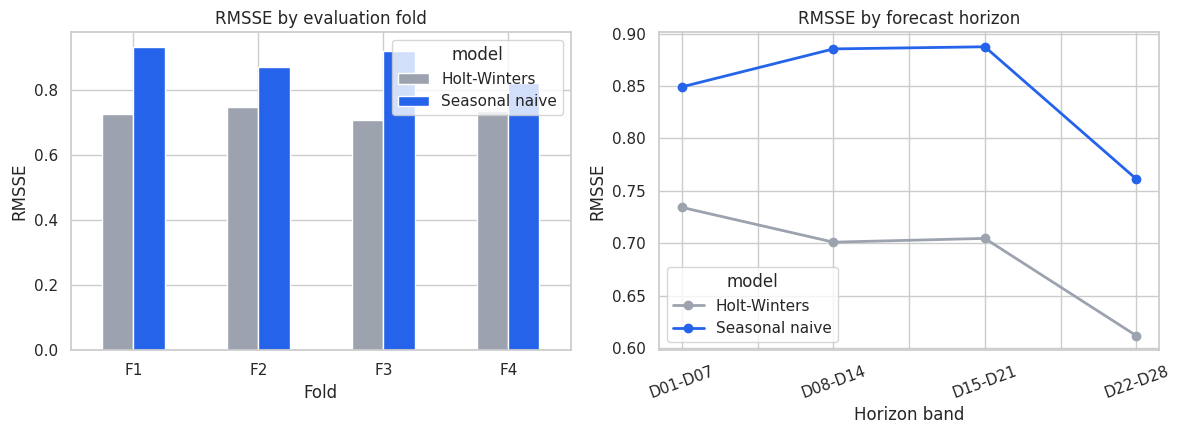

In [12]:
fold_results = (
    baseline_metrics.query("scope == 'fold'")
    .pivot(index="fold_id", columns="model", values="rmsse")
    .rename(
        columns={
            "seasonal_naive_7": "Seasonal naive",
            "holt_winters_add_damped_7": "Holt-Winters",
        }
    )
)
horizon_results = (
    baseline_metrics.query("scope == 'horizon_band'")
    .pivot(index="horizon_band", columns="model", values="rmsse")
    .rename(
        columns={
            "seasonal_naive_7": "Seasonal naive",
            "holt_winters_add_damped_7": "Holt-Winters",
        }
    )
    .reindex(["D01-D07", "D08-D14", "D15-D21", "D22-D28"])
)
display(fold_results)
display(horizon_results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fold_results.plot(kind="bar", ax=axes[0], color=["#9CA3AF", "#2563EB"])
axes[0].set(title="RMSSE by evaluation fold", xlabel="Fold", ylabel="RMSSE")
axes[0].tick_params(axis="x", rotation=0)
horizon_results.plot(
    kind="line",
    marker="o",
    linewidth=2,
    ax=axes[1],
    color=["#9CA3AF", "#2563EB"],
)
axes[1].set(title="RMSSE by forecast horizon", xlabel="Horizon band", ylabel="RMSSE")
axes[1].tick_params(axis="x", rotation=20)
fig.tight_layout()
display(fig)
plt.close(fig)


The overall score can hide changes between months or between early and late forecast days. I therefore compare performance by fold and by seven-day horizon band.


In [13]:
series_fold = baseline_metrics.query("scope == 'series_fold'").pivot(
    index=["fold_id", "series_id"], columns="model", values="rmsse"
)
series_mean = series_fold.groupby("series_id").mean()
holt_wins = int(
    (series_mean["holt_winters_add_damped_7"] < series_mean["seasonal_naive_7"])
    .sum()
)
comparison = (
    series_mean.assign(
        rmsse_improvement=(
            series_mean["seasonal_naive_7"]
            - series_mean["holt_winters_add_damped_7"]
        )
    )
    .sort_values("rmsse_improvement", ascending=False)
)

print(f"Holt-Winters has lower mean fold RMSSE for {holt_wins} of 30 series.")
display(comparison.head(10))


Holt-Winters has lower mean fold RMSSE for 30 of 30 series.


model,holt_winters_add_damped_7,seasonal_naive_7,rmsse_improvement
series_id,,,
HOBBIES_CA_4,0.8449,1.1660,0.3211
HOUSEHOLD_WI_2,1.1736,1.4258,0.2521
HOBBIES_TX_2,0.6046,0.8553,0.2507
FOODS_WI_1,0.6410,0.8899,0.2488
HOUSEHOLD_CA_1,0.4774,0.7243,0.2469
HOBBIES_TX_3,0.7461,0.9836,0.2375
HOBBIES_WI_1,0.5040,0.7308,0.2268
HOUSEHOLD_TX_3,0.8774,1.0963,0.2189
HOBBIES_CA_3,0.5614,0.7794,0.2181


## 8. Summary and limitations

The processed data passed the structural checks, and Holt-Winters was the better baseline. The saved panel, forecasts and metrics are used directly in Notebook 03.

Limitations to carry forward are:

1. Category-store forecasts cannot directly determine SKU replenishment quantities.
2. Holt-Winters represents weekly seasonality but does not directly use events or SNAP indicators.
3. Point forecasts do not quantify predictive uncertainty.
4. Performance over four folds provides stronger evidence than one holdout, but it does not represent every possible retail regime.

Notebook 03 now tests whether one recursive LightGBM model improves on both baselines without using future demand information.


In [14]:
notebook_02_outputs = [
    panel_path,
    powerbi_dir / "fact_forecasts_baselines.csv",
    metrics_dir / "rmsse_scales.csv",
    metrics_dir / "forecast_metrics_baselines.csv",
]
assert all(path.is_file() for path in notebook_02_outputs)
print("NOTEBOOK 02 COMPLETED SUCCESSFULLY")


NOTEBOOK 02 COMPLETED SUCCESSFULLY
